In [1]:
import sys
sys.path.append('../src')

from IPython.display import display, clear_output
from PIL import Image, ImageOps, ImageDraw, ImageFont, ImageChops
import matplotlib.pyplot as plt
import numpy as np

from palette.symbol2value import get_asciis, symbols_sorted
from image.processing import preprocess_img
from rendering.image import render_symbols_img
from converters.line_heuristics.utils import evaluate_symbol_arr

In [2]:
FONT = ImageFont.truetype("../fonts/OpenSans-Regular.ttf", 18)
# FONT = ImageFont.truetype("../fonts/Inconsolata-Regular.ttf", 18)

CHAR_SET = symbols_sorted(get_asciis(), FONT)[::2]
print(CHAR_SET)
print(len(CHAR_SET))

IMG_PATH = "../imgs/irad_grad.bmp"

[' ', '`', ',', ':', ';', '"', 'i', '+', '<', '>', '^', 'r', '?', 't', ')', 'c', 'f', 'J', '{', '7', 'v', ']', 'T', 'F', 'o', 'C', 'a', 'y', '5', 'S', '4', 'X', '6', 'P', '9', 'U', 'b', 'p', '$', 'H', 'G', 'O', 'w', 'g', 'N', '&', '@', 'W']
48


(512, 512)
(102, 102)


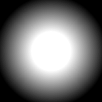

In [3]:
orig_img = Image.open(IMG_PATH).convert("L")
print(orig_img.size)
prep_img = preprocess_img(orig_img, 0.2, contrast=2.0)
print(prep_img.size)
display(prep_img)

[[' ', ' ', ' ', '@', '@', '@', 'g', 'g', ',', ' ', ' ', ' '], ['@', '@', '@', '@', '@', '@', ','], ['@', '@', '@', '@', '@', '@', '`'], [' ', ' ', '"', '@', '@', '@', '@', '"', ' ', ' ', ' ']]
-13884.412533640907


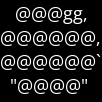

In [4]:
from converters.line_heuristics.greedy import GreedyLineSearch

res_arr = GreedyLineSearch(CHAR_SET, FONT).process_image(prep_img)
print(res_arr)
print(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
display(render_symbols_img(res_arr, FONT, wh=prep_img.size))

[['`', '`', 'G', 'c', '@', ']', 't', ']', 'S', ';', ';', 'H'], ['"', 'S', 'a', 'G', ']', '6', ']', 'G', '&', 'P'], [']', '@', 'p', ']', 'g', '9', '@', '7', '$', 'a'], [',', '"', 'p', '?', 'P', '@', 'f', 'i', 'g', '`', 'r', '>']]
-14820.894271434065


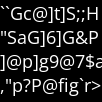

In [5]:
from converters.line_heuristics.random_search import RandomLineSearch

res_arr = RandomLineSearch(CHAR_SET, FONT, 300).process_image(prep_img)
print(res_arr)
print(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
display(render_symbols_img(res_arr, FONT, wh=prep_img.size))

-13388.82737408689
[[',', ' ', '<', 'g', 'g', '6', 'g', 'g', 'O', ':', '+', '$', ')', 'o', '^', 'f', 'G', 'U', ' ', 'W'], [',', '5', '6', 'g', 'g', 'J', 'g', 'g', 'g', 'g', '@', 'c', 'G', 'o', 'g', 'o', '`', 'S', '+', 'g'], ['>', '@', '9', 'g', 'g', 'g', 'g', '@', 'w', 'r', ';', '<', '7', 'S', '`', 'U', 'g', 'r', 't', '6'], [' ', '"', '?', '@', '9', '{', 'f', 'P', '@', '?', '"', 'N', '5', '@', 'U', ';', 'i', ')', ' ', ')']]


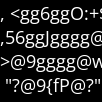

In [6]:
from converters.line_heuristics.harmony_search import HarmonyLineSearch

res_arr = HarmonyLineSearch(CHAR_SET, FONT, generations=200, pop_count=20, mem_rate=0.6, pa_rate=0.2, pa=len(CHAR_SET) // 4).process_image(prep_img)
print(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
print(res_arr)
display(render_symbols_img(res_arr, FONT, wh=prep_img.size))


0 -5450.191176470588
2 -5169.967320261438
4 -5144.973856209151
5 -5120.722222222223
6 -4807.606209150327
13 -4789.588235294118
16 -4666.589869281046
18 -4629.503267973856
20 -4614.431372549019
23 -4490.746732026144
24 -4461.821895424837
27 -4443.138888888889
30 -4394.684640522876
48 -4359.119281045751
61 -4335.923202614379
68 -4321.178104575163
81 -4297.982026143791
1 -22090.36274509804
2 -21961.843137254902
3 -21789.210784313724
5 -21782.916666666668
6 -21239.944444444445
9 -21109.549019607843
12 -20835.56862745098
18 -20784.254901960783
21 -20740.434640522875
24 -20732.952614379086
25 -20675.263071895424
26 -20647.36111111111
28 -20580.722222222223
32 -20497.839869281044
37 -20471.772875816994
44 -20470.933006535946
46 -20466.830065359478
47 -20451.442810457516
49 -20428.839869281044
56 -20419.267973856207
1 -25917.46405228758
2 -25724.55065359477
3 -25701.710784313724
4 -25655.460784313724
5 -25459.843137254902
6 -25203.805555555555
9 -24985.69934640523
16 -24922.529411764706
18 -24

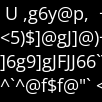

In [7]:
from converters.line_heuristics.genetic_search import GeneticLineSearch

res_arr = GeneticLineSearch(CHAR_SET, FONT, generations=300, pop_count=50).process_image(prep_img)
print(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
display(render_symbols_img(res_arr, FONT, wh=prep_img.size))

[['C', '5', '@', ')', 'J', 'y', 'J', 'y', '@', ' ', '^', 'o', 'a', '^', 'b', 'F', 'O', 'f', 'c', 'N'], ['5', '5', '9', 'J', 'g', ')', '$', 'J', 'g', 'p', 'S', 'r', '^', '$', 'J', '5', 'y', 'W', 'G', 'O'], ['O', ']', '@', '$', 'g', ']', 'g', ']', '9', '>', 'T', '5', 'H', 'c', 'P', 'y', 'F', 'c', '4', '4'], ['<', '^', '@', ']', '@', 'P', 'f', 'f', '^', '^', 'o', 'J', 'b', 'P', 'C', '9', '`', '7', 'U', ')']]
-13828.423298731257


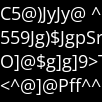

In [8]:
from converters.line_heuristics.pso_search import ParticleSwarmLineSearch

res_arr = ParticleSwarmLineSearch(CHAR_SET, FONT, generations=300, pop_count=50, innertion=0.3, cog_coeff=0.9, soc_coeff=1.2).process_image(prep_img)
print(res_arr)
print(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
display(render_symbols_img(res_arr, FONT, wh=prep_img.size))